In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"H:\WGUData\teleco_time_series .csv")

Section A:
A1. Research Question

Can historical daily revenue be used to forecast future revenue over the next period in order to support financial planning and business decision-making?

A2. Objective

The objective of this data analysis is to develop a time series model that can accurately forecast future daily revenue based on historical patterns. By analyzing trends, temporal dependencies, and potential cyclical behavior in the data, the model aims to provide reliable short-term revenue predictions.

These forecasts can support organizational decision-making by improving financial planning, resource allocation, and performance monitoring. The analysis is limited to the available daily revenue data and focuses on identifying patterns that can be captured using time series modeling techniques such as ARIMA. (Overload, 2023)


Section B:
B1. Assumptions 

Time series models rely on several key assumptions to produce reliable forecasts. One primary assumption is stationarity, meaning the time series has a constant mean and variance over time and follows a stable statistical distribution. If a series is nonstationary due to trends or seasonality, transformations such as differencing may be applied to stabilize it before modeling.
Another important assumption is that the error terms are uncorrelated and randomly distributed, meaning they have a mean of zero and constant variance over time. This ensures that the model has captured the underlying structure of the data and that no systematic patterns remain in the residuals. Tests such as the Durbin-Watson statistic can be used to detect autocorrelation in the residuals.
Time series analysis also assumes that there are no significant outliers in the data, as extreme values can distort patterns and lead to misleading model results. Additionally, any random shocks affecting the series are assumed to be unpredictable, with a mean of zero and constant variance, reinforcing the assumption that the remaining variation behaves like random noise.
Finally, time series models account for autocorrelation, where current observations are correlated with past values. This relationship is essential for models such as ARIMA, which use past observations and errors to forecast future values. (Time Series Analysis, n.d.)


In [3]:
print(df.head())
print(df.info())

   Day   Revenue
0    1  0.000000
1    2  0.000793
2    3  0.825542
3    4  0.320332
4    5  1.082554
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Day      731 non-null    int64  
 1   Revenue  731 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 11.6 KB
None


Section C:

C1. Line Graph

A line graph was created to visualize the realization of the time series. The dataset contains daily revenue observations, where each data point represents the total revenue generated on a specific day. The resulting plot shows revenue values over time, allowing for the identification of patterns such as trends and fluctuations.

The visualization reveals a clear upward trend in revenue over time, along with short-term variability. This indicates that revenue has generally increased across the observed period, suggesting the presence of a nonstationary trend component. The line graph provides an initial understanding of the behavior of the time series and serves as the foundation for further analysis.

C2. Time Step Formatting

The time series is recorded at daily intervals, where each observation represents revenue for a specific day. The “Day” variable was converted to a datetime format and used as the index to ensure proper chronological ordering of the data.

The dataset consists of regularly spaced daily observations with no missing time intervals, forming a continuous and evenly spaced time series. This structure satisfies the requirements for time series modeling, as it ensures consistent time steps and allows for accurate identification of temporal patterns such as trends and seasonality.

C3. Evaluation of stationarity

The stationarity of the time series was evaluated using both visual inspection and statistical testing. The initial time series plot showed a clear upward trend in revenue over time, indicating that the mean of the series changes over time. This suggests that the series is nonstationary.

To confirm this observation, an Augmented Dickey-Fuller (ADF) test was performed on the original series. The test produced an ADF statistic of -1.9462 and a p-value of 0.3206. Because the p-value is greater than 0.05, the null hypothesis of nonstationarity cannot be rejected, confirming that the original series is nonstationary.

To address this issue, first-order differencing was applied to remove the trend and stabilize the mean of the series. The differenced time series plot showed that the upward trend was removed and that the values fluctuate around a constant mean, providing visual evidence of stationarity.

The ADF test was then performed on the differenced series, resulting in an ADF statistic of -44.8745 and a p-value of 0.0000. Because the p-value is less than 0.05, the null hypothesis of nonstationarity is rejected, indicating that the differenced series is stationary and suitable for time series modeling.


C4. Data Preparation

The data preparation process involved converting the dataset into a format suitable for time series analysis. First, the “Day” variable was converted to a datetime format and set as the index to establish a proper time-based structure. The dataset was then sorted chronologically to ensure correct temporal sequencing.

The dataset was examined for missing values and gaps in the time index. No missing dates or values were identified that would impact the analysis, allowing the time series to remain continuous without the need for imputation or interpolation. The cleaned CSV file will be provided with the assignment submission.

The revenue variable was selected as the target variable for analysis, resulting in a univariate time series. The stationarity of the series was evaluated, and first-order differencing was applied to remove the trend and stabilize the mean.

Finally, the data were split into training and test sets using a chronological split, where the earlier observations were used for model training and the most recent observations were reserved for evaluating forecast performance.


In [4]:
# Convert Day to numeric (if not already)
df["Day"] = pd.to_numeric(df["Day"])

# Create a proper daily date range
df["Day"] = pd.date_range(start="2020-01-01", periods=len(df), freq="D")

# Set as index
df = df.set_index("Day")

# Extract time series
ts = df["Revenue"]

print(ts.head())

Day
2020-01-01    0.000000
2020-01-02    0.000793
2020-01-03    0.825542
2020-01-04    0.320332
2020-01-05    1.082554
Name: Revenue, dtype: float64


In [5]:
ts.to_csv("cleaned_time_series.csv")

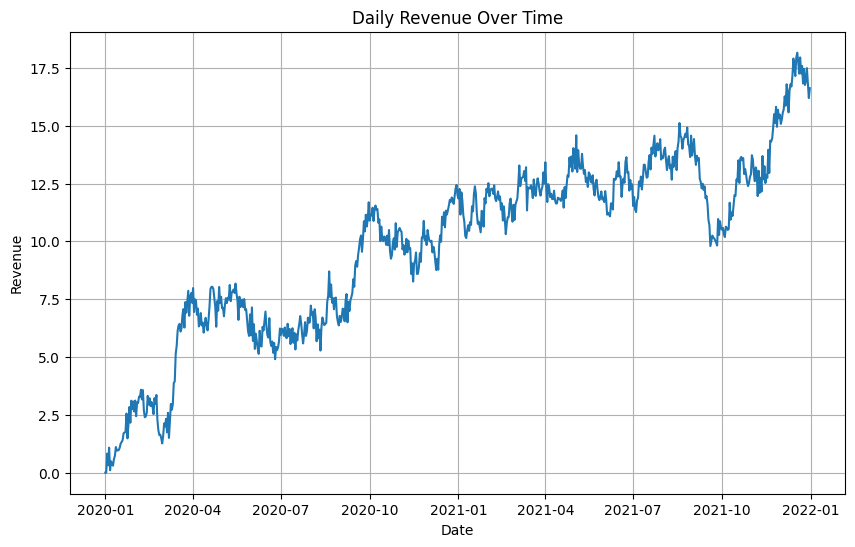

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(ts)
plt.title("Daily Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

In [7]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of lags used:", adf_result[2])
print("Number of observations:", adf_result[3])

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -1.924612157310183
p-value: 0.3205728150793967
Number of lags used: 1
Number of observations: 729

Critical Values:
1%: -3.4393520240470554
5%: -2.8655128165959236
10%: -2.5688855736949163


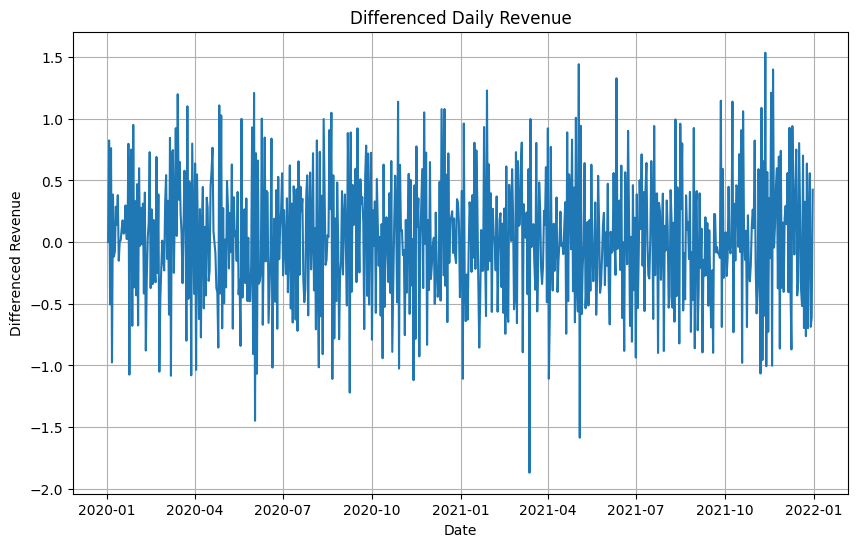

In [8]:
# First-order differencing
ts_diff = ts.diff().dropna()

# Plot differenced series
plt.figure(figsize=(10,6))
plt.plot(ts_diff)
plt.title("Differenced Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Differenced Revenue")
plt.grid(True)
plt.show()

In [9]:
adf_result_diff = adfuller(ts_diff)

print("ADF Statistic (Differenced):", adf_result_diff[0])
print("p-value (Differenced):", adf_result_diff[1])

ADF Statistic (Differenced): -44.87452719387599
p-value (Differenced): 0.0


In [10]:
# Train-test split (chronological)
train_size = int(len(ts) * 0.8)

train = ts.iloc[:train_size]
test = ts.iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

print("\nTrain head:")
print(train.head())

print("\nTest head:")
print(test.head())

Train size: 584
Test size: 147

Train head:
Day
2020-01-01    0.000000
2020-01-02    0.000793
2020-01-03    0.825542
2020-01-04    0.320332
2020-01-05    1.082554
Name: Revenue, dtype: float64

Test head:
Day
2021-08-07    13.684826
2021-08-08    13.152903
2021-08-09    13.310290
2021-08-10    12.665601
2021-08-11    13.660658
Name: Revenue, dtype: float64


In [11]:
df.to_csv("differenced_time_dataset.csv", index=False)

Section D:

D1. Findings and Visualizations

The time series data were analyzed using multiple visualization and diagnostic techniques to identify trends, seasonality, and underlying structure.


Trend Analysis

The initial time series plot revealed a clear upward trend in daily revenue over time, indicating sustained growth throughout the observed period. Although short-term fluctuations are present, the overall pattern shows a consistent increase in revenue. This upward trend suggests that the mean of the series is not constant over time, indicating nonstationarity.


Autocorrelation Function (ACF)

The autocorrelation function (ACF) plot showed strong positive autocorrelation across many lags, with values decreasing gradually rather than dropping off sharply. This slow decay indicates a high degree of persistence in the time series, meaning that current revenue values are strongly influenced by past values.

The extended autocorrelation structure further confirms the presence of a trend in the data. No clear repeating spikes at regular intervals were observed, suggesting that while the series exhibits strong dependence over time, there is limited evidence of distinct seasonal cycles based solely on the ACF.


Spectral Density Analysis

A spectral density analysis (periodogram) was conducted to identify any cyclical or periodic behavior in the data. The periodogram displayed a dominant peak at very low frequencies, indicating that most of the variation in the time series occurs over long time horizons.

This pattern is consistent with the strong upward trend observed in the data rather than true seasonal behavior. The absence of significant peaks at higher frequencies suggests that there are no strong repeating cycles or periodic patterns in the series.


Decomposition of Time Series

A seasonal decomposition was performed using an additive model with a period of 7 to evaluate potential weekly seasonality. The decomposition separated the series into trend, seasonal, and residual components.

The trend component clearly reflects the overall upward movement in revenue over time, confirming the presence of a strong long-term trend. The seasonal component shows a consistent repeating pattern across observations, suggesting the presence of short-term cyclical behavior. Given the daily structure of the dataset, this pattern may reflect weekly fluctuations in revenue.

However, the magnitude of the seasonal component is relatively small compared to the overall trend, indicating that trend is the dominant feature of the series.


Residual Analysis

The residual component of the decomposed series was examined to determine whether any systematic patterns remained after accounting for trend and seasonality. The residuals fluctuate randomly around zero with no visible trend or repeating structure.

This indicates that the primary patterns in the data have been effectively captured by the trend and seasonal components, and that the residuals behave like random noise. This supports the adequacy of the decomposition in representing the underlying structure of the time series.


<Figure size 800x500 with 0 Axes>

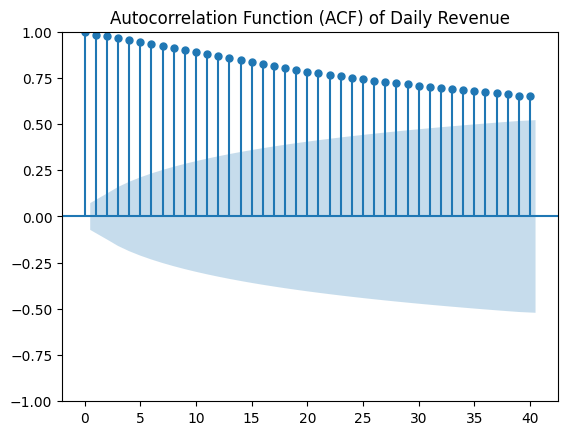

In [12]:
#ACF visualization
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8,5))
plot_acf(ts, lags=40)
plt.title("Autocorrelation Function (ACF) of Daily Revenue")
plt.show()

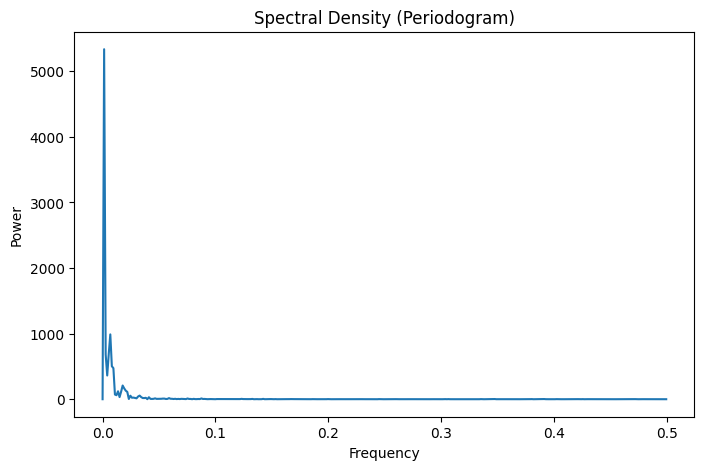

In [13]:
# Spectral Density
from scipy.signal import periodogram

freqs, power = periodogram(ts)

plt.figure(figsize=(8,5))
plt.plot(freqs, power)
plt.title("Spectral Density (Periodogram)")
plt.xlabel("Frequency")
plt.ylabel("Power")
plt.show()

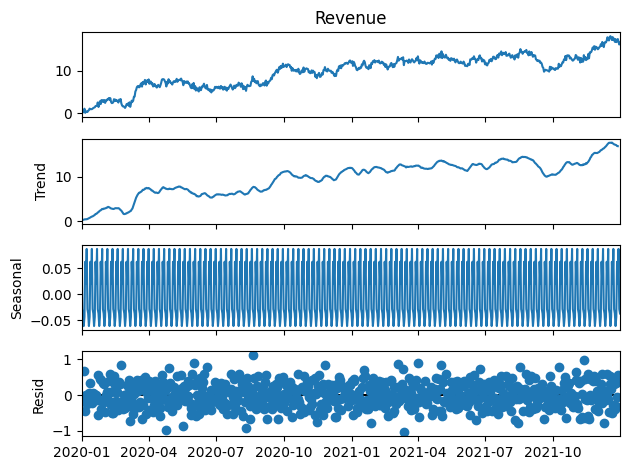

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomp = seasonal_decompose(ts, model="additive", period=7)

decomp.plot()
plt.show()

D2. ARIMA Model

An autoregressive integrated moving average (ARIMA) model was selected to capture the trend and structure of the time series data. Based on the stationarity analysis, first-order differencing was required, resulting in d=1.

The autocorrelation function (ACF) showed strong persistence with gradual decay, indicating short-term dependencies in the data. Therefore, both autoregressive and moving average components were included, resulting in an ARIMA(1,1,1) model.

The fitted model produced an AIC value of 776.033 and a log likelihood of -385.016. The autoregressive term was statistically significant (p < 0.001), indicating that past values influence current observations, while the moving average term was not statistically significant.

Diagnostic tests indicated a good model fit. The Ljung-Box test (p = 0.89) showed no significant autocorrelation in the residuals, and the Jarque-Bera test (p = 0.40) suggested the residuals are approximately normally distributed.

Overall, the ARIMA(1,1,1) model adequately captures the trend and temporal dependencies in the data and is suitable for forecasting. (Overload, 2023)


In [15]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  584
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -385.016
Date:                Mon, 13 Apr 2026   AIC                            776.033
Time:                        11:36:35   BIC                            789.137
Sample:                    01-01-2020   HQIC                           781.141
                         - 08-06-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4610      0.078     -5.921      0.000      -0.614      -0.308
ma.L1          0.0041      0.087      0.047      0.962      -0.166       0.174
sigma2         0.2193      0.014     15.948      0.0

C:\Users\Batman\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Batman\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Batman\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


D3. Forecast Model

A forecast was generated using the ARIMA(1,1,1) model to evaluate model performance and predict future revenue values. First, an in-sample forecast was produced by training the model on the training dataset and comparing predictions to the test dataset. The model demonstrated reasonable performance, with an RMSE of approximately 2.18, indicating that predicted values were generally close to actual observations.

In addition to the in-sample evaluation, an out-of-sample forecast was generated by retraining the ARIMA(1,1,1) model on the full dataset and projecting future revenue values for the next 30 days. This forecast provides insight into expected future behavior beyond the observed data.

The out-of-sample forecast includes prediction intervals, which represent the range within which future observations are expected to fall with a given level of confidence. These intervals widen as the forecast horizon increases, reflecting growing uncertainty in longer-term predictions.

The visualization shows that the model forecasts a relatively stable level of revenue while the prediction intervals capture the potential variability in future outcomes. This indicates that while the model provides a reasonable estimate of future revenue levels, there is inherent uncertainty that should be considered when interpreting the results.


Forecast vs Actual:
               Actual   Forecast
2021-08-07  13.684826  13.311132
2021-08-08  13.152903  13.400459
2021-08-09  13.310290  13.359276
2021-08-10  12.665601  13.378263
2021-08-11  13.660658  13.369509
...               ...        ...
2021-12-27  16.931559  13.372271
2021-12-28  17.490666  13.372271
2021-12-29  16.803638  13.372271
2021-12-30  16.194813  13.372271
2021-12-31  16.620798  13.372271

[147 rows x 2 columns]


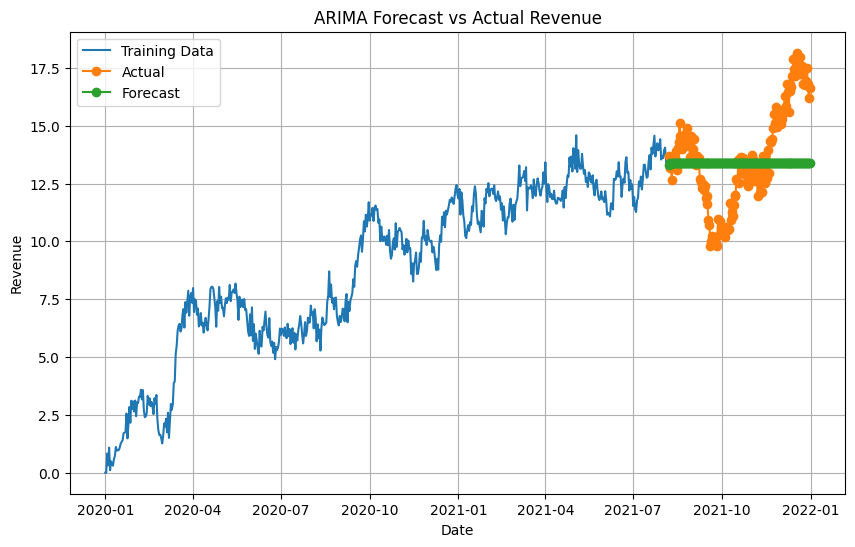

In [16]:
# Forecast
forecast = model_fit.forecast(steps=len(test))

# Comparison table
comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast
})

print("Forecast vs Actual:")
print(comparison)


plt.figure(figsize=(10,6))

# Training data
plt.plot(train, label="Training Data")

# Test data
plt.plot(test, label="Actual", marker='o')

# Forecast
plt.plot(forecast, label="Forecast", marker='o')

plt.title("ARIMA Forecast vs Actual Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)

plt.show()

In [17]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, forecast))
print("RMSE:", rmse)

RMSE: 2.176510025315691


C:\Users\Batman\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Batman\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Batman\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


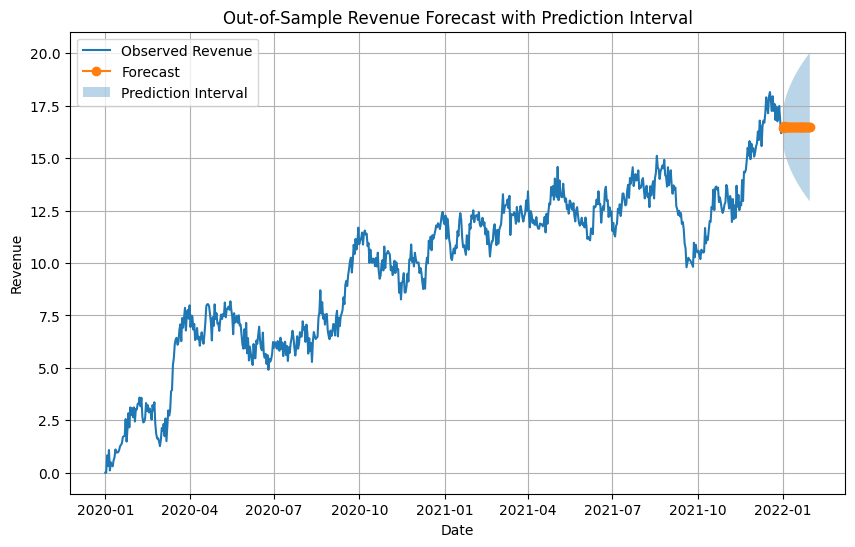

In [18]:
# Out-of-sample forecast with prediction interval

# Retrain model on full original series
model_full = ARIMA(ts, order=(1, 1, 1))
model_full_fit = model_full.fit()

# Forecast future values
steps = 30  
forecast_result = model_full_fit.get_forecast(steps=steps)

forecast = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# Plot observed data and future forecast
plt.figure(figsize=(10, 6))

plt.plot(ts, label="Observed Revenue")
plt.plot(forecast, label="Forecast", marker="o")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.3,
    label="Prediction Interval"
)

plt.title("Out-of-Sample Revenue Forecast with Prediction Interval")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.show()

Section E:

E1. Results of analysis

The ARIMA(1,1,1) model was selected based on the observed characteristics of the time series data. The original series exhibited a clear upward trend, and stationarity was achieved through first-order differencing. The autocorrelation structure supported the inclusion of autoregressive and moving average components.

The model was evaluated using both in-sample and out-of-sample forecasting approaches. The in-sample forecast demonstrated reasonable accuracy, with an RMSE of approximately 2.18.

The out-of-sample forecast provided predictions for future revenue values and included prediction intervals, which represent a range of plausible outcomes. These intervals widen over time, reflecting increased uncertainty in longer-term forecasts. This highlights that while the model provides useful estimates of future revenue levels, actual values may vary within the predicted range.


E2. Visualization Of Forecast Model

The forecast visualization includes both the observed time series and the out-of-sample forecast generated by the ARIMA(1,1,1) model. The forecast line represents the expected future revenue values, while the shaded region surrounding the forecast represents the prediction interval.

The prediction interval illustrates the uncertainty associated with future predictions, showing a range within which actual values are likely to fall. As the forecast extends further into the future, the interval widens, indicating increasing uncertainty.

This visualization demonstrates that while the model predicts relatively stable future revenue, there is variability captured by the prediction interval that should be considered when making decisions based on the forecast.


E3. Recommended Course of Action

Based on the analysis, the ARIMA(1,1,1) model provides a reasonable estimate of future revenue levels and is suitable for short-term forecasting. However, the model’s relatively stable forecast and widening prediction intervals indicate that it may not fully capture short-term fluctuations or changes in trend.

It is recommended that the organization use this model for general forecasting and planning purposes while recognizing the uncertainty reflected in the prediction intervals. For improved accuracy, future analyses could incorporate additional variables or more advanced models that better capture variability and potential seasonality in the data.


Sources: 

Overload, D. (2023, June 17). Understanding ARIMA Models: A Comprehensive Guide to Time Series Forecasting. Medium. https://medium.com/@data-overload/understanding-arima-models-a-comprehensive-guide-to-time-series-forecasting-dfc7207f2406

Time Series Analysis. (n.d.). Statistics Solutions. https://www.statisticssolutions.com/free-resources/directory-of-statistical-analyses/time-series-analysis/